# <center>**Importing Essential Libraries and Defining Dataset Paths**</center>

In [2]:
# Standard libraries
import os
import re
import copy
import time
import random
from pathlib import Path
from collections import Counter, defaultdict
import shutil
import math


# Data handling
import pandas as pd
import numpy as np
from scipy.stats import skew
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pillow_heif

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
from torchvision import datasets, models, transforms
import torchvision.transforms.v2 as v2

# Enable HEIF/HEIC support
pillow_heif.register_heif_opener()

# ----------------------------
# Environment logging
# ----------------------------
print("=== Environment Info ===")
print(f"OS: {os.name}")
print(f"Python version: {os.sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

if torch.backends.mps.is_available():
    print("Apple GPU (MPS) available: Yes")
else:
    print("Apple GPU (MPS) available: No")

=== Environment Info ===
OS: posix
Python version: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:54:21) [Clang 16.0.6 ]
PyTorch version: 2.5.1
Torchvision version: 0.20.1
Numpy version: 1.26.4
Pandas version: 2.2.2
Matplotlib version: 3.9.2
Seaborn version: 0.13.2
Apple GPU (MPS) available: Yes


In [3]:
# ============================================================
# Project / Dataset Paths
# ============================================================

from dotenv import load_dotenv

# Permanent private configuration
CONFIG_FILE = Path.home() / ".wadidegla.env"

if not CONFIG_FILE.exists():
    raise FileNotFoundError(
        "Local WadiDegla configuration file was not found."
    )

load_dotenv(CONFIG_FILE)


DATA_DIR = Path(os.environ["WADIDEGLA_DATA_DIR"])
TRAIN_DIR = DATA_DIR / "Train"
VAL_DIR = DATA_DIR / "Validation"

WORKSPACE_DIR = Path(os.environ["WADIDEGLA_WORKSPACE_DIR"])

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "The configured WadiDegla dataset directory does not exist."
    )

if not WORKSPACE_DIR.exists():
    raise FileNotFoundError(
        "The configured WadiDegla experimental workspace directory does not exist."
    )

print("WadiDegla dataset configuration loaded successfully.")
print("WadiDegla experimental workspace configuration loaded successfully.")

WadiDegla dataset configuration loaded successfully.
WadiDegla experimental workspace configuration loaded successfully.


# **<center>Results visualization</center>**

## Phase 1

In [87]:
from pathlib import Path
import pandas as pd
import os
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
def load_and_clean_summary(folder, summary_type="Validation"):
    main_df = pd.DataFrame()

    for file in sorted(os.listdir(folder)):
        if file.endswith(".csv"):
            path = os.path.join(folder, file)
            df = pd.read_csv(path)

            # Extract stage
            parts = file.split("_")
            stage = next((p for p in parts if p.lower().startswith("stage")), "unknown")
            df["Stage"] = stage
            df["SummaryType"] = summary_type

            # Scale alidation metrics
            if summary_type.lower().startswith("validation"):
                for col in ["Precision (macro)", "Recall (macro)", "F1 (macro)"]:
                    if col in df.columns:
                        df[col] = df[col] * 100

            # Remove any rows from main_df that have the same Epoch values as in df
            if "Epoch" in df.columns and not main_df.empty:
                epochs = df["Epoch"].unique()
                main_df = main_df[~main_df["Epoch"].isin(epochs)]

            # Concatenate
            main_df = pd.concat([main_df, df], ignore_index=True)

    return main_df.sort_values(["Stage", "Epoch"])

In [12]:
def visualize_metrics(train_summary, val_summary, version, save=False):
    """
    Visualize Accuracy, Precision, Recall, and F1 metrics across epochs.
    Two plots per row, no markers, vertical lines and stage labels at stage start.
    """
    combined_df = pd.concat([train_summary, val_summary])
    stage_map = {
    "stageA": "Stage 1",
    "stageB": "Stage 2",
    "stageC": "Stage 3",
    "stageD": "Stage 4",
    "stageE": "Stage 5"
                }
    combined_df["Stage"] = combined_df["Stage"].replace(stage_map)
    metrics = ["Accuracy (micro)", "F1 (macro)", "Precision (macro)", "Recall (macro)"]
    metrics_titles = ["a) Accuracy (micro)", "b) F1-score (macro)", "c) Precision (macro)", "d) Recall (macro)"]
    n_plots = len(metrics)

    fig, axes = plt.subplots((n_plots + 1) // 2, 2, figsize=(18, 5 * ((n_plots + 1) // 2)))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        for stype, subset in combined_df.groupby("SummaryType"):
            if stype == 'Train':
                stype = 'Training'
            ax.plot(subset["Epoch"], subset[metric], label=stype, linewidth=2)
        
        # Stage annotations
        for stage in combined_df["Stage"].unique():
            se = combined_df.loc[combined_df["Stage"] == stage, "Epoch"]
            if not se.empty:
                ax.axvline(x=se.min(), color="gray", linestyle="--", alpha=0.3)
                ax.text(se.min(), ax.get_ylim()[1], stage, rotation=90, va="top",
                        fontsize=15, color="black")
        
        ax.set_title(metrics_titles[i], fontsize=18)
        ax.set_xlabel("Epoch", fontsize=16)
        ax.set_ylabel(metrics_titles[i][2:], fontsize=16)
        ax.legend(loc='lower right', fontsize=15)
        ax.grid(alpha=0.3)
    
    # Remove unused subplots
    for idx in range(n_plots, len(axes)):
        fig.delaxes(axes[idx])
    fig.suptitle(f'Training and Validation Metrics Across Stages', fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    if save:
        plt.savefig(f"Phase 1/Train_val_Metrics_{version}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [101]:
train_dir = WORKSPACE_DIR / 'Phase 1/mobilenetv2/train_summary'

In [102]:
val_dir = WORKSPACE_DIR / 'Phase 1/mobilenetv2/val_summary'

In [103]:
train_summary = load_and_clean_summary(train_dir, "Train")
val_summary = load_and_clean_summary(val_dir, "Validation")

In [104]:
train_summary.to_csv('Phase 1/train_summary.csv', index=False)
val_summary.to_csv('Phase 1/val_summary.csv', index=False)

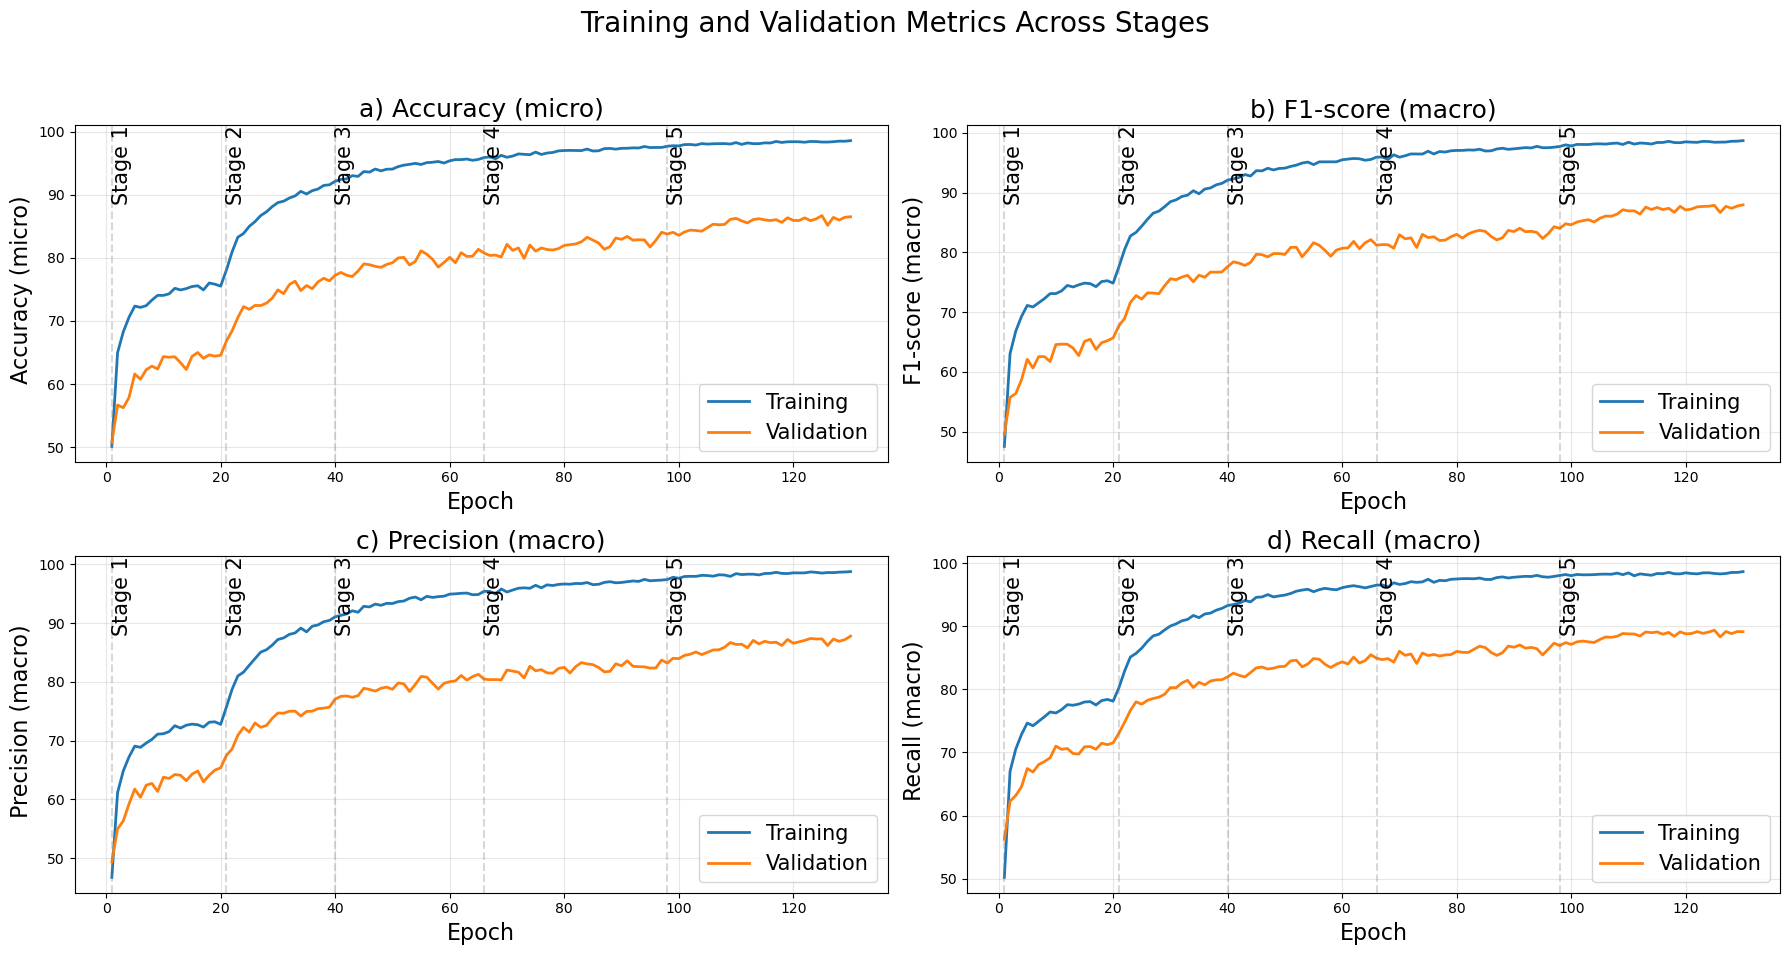

In [105]:
visualize_metrics(train_summary, val_summary, version='version_2', save=True)

In [13]:
def visualize_loss(train_summary, val_summary, version, save=False):
    """
    Visualize Loss metric across epochs.
    """
    combined_df = pd.concat([train_summary, val_summary])
    stage_map = {
    "stageA": "Stage 1",
    "stageB": "Stage 2",
    "stageC": "Stage 3",
    "stageD": "Stage 4",
    "stageE": "Stage 5"
                }
    combined_df["Stage"] = combined_df["Stage"].replace(stage_map)
    
    plt.figure(figsize=(10, 5))
    for stype, subset in combined_df.groupby("SummaryType"):
        if stype == 'Train':
                stype = 'Training'
        plt.plot(subset["Epoch"], subset["Loss"], label=stype, linewidth=2)
    
    # Stage annotations
    for stage in combined_df["Stage"].unique():
        se = combined_df.loc[combined_df["Stage"] == stage, "Epoch"]
        if not se.empty:
            plt.axvline(x=se.min(), color="gray", linestyle="--", alpha=0.3)
            plt.text(se.min(), plt.ylim()[1], stage, rotation=90, va="top", fontsize=9, color="black")
    
    plt.title("Training and Validation Loss Across Stages", pad=20)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    if save:
        plt.savefig(f"Phase 1/Train_val_Loss_{version}.png", dpi=300, bbox_inches="tight")
    plt.show()

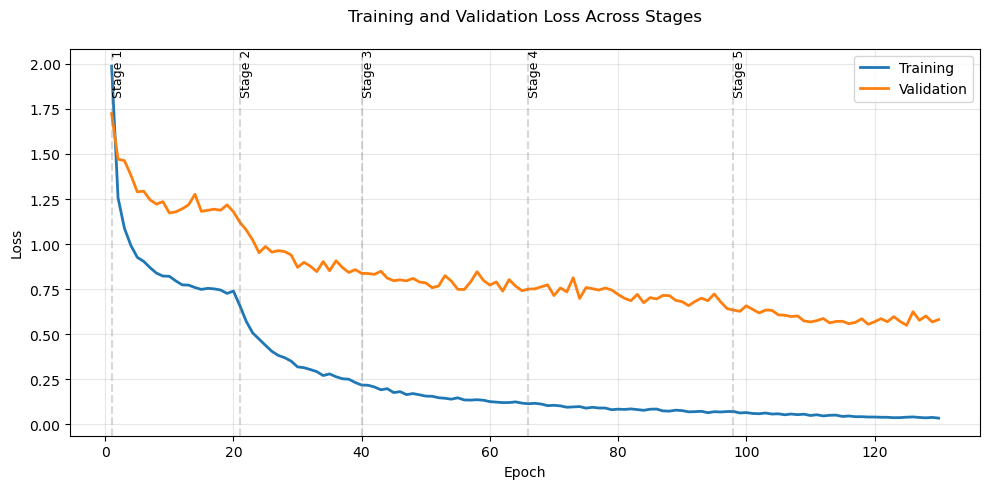

In [108]:
visualize_loss(train_summary, val_summary, version='version_2', save=True)

**Table 6: Progressive Unfreezing Schedule for Phase 1 Training**

| Stage | Trainable Blocks / Description                  | Trainable Params | Total Params | Trainable % | Learning Rate | Start Epoch | End Epoch |
| ----- | ----------------------------------------------- | ---------------- | ------------ | ----------- | ------------- | ----------- | --------- |
| A     | Classifier only                                 | 42,273           | 2,266,145    | 1.87%       | 1e-3          | 1           | 20        |
| B     | Newly unfrozen blocks: [17, 18]                 | 928,353          | 2,266,145    | 40.97%      | 1e-4          | 21          | 39        |
| C     | Newly unfrozen blocks: [15, 16]                 | 1,568,353        | 2,266,145    | 69.21%      | 5e-5          | 40          | 65        |
| D     | Newly unfrozen blocks: [13, 14]                 | 1,841,889        | 2,266,145    | 81.28%      | 3e-5          | 66          | 97        |
| E     | Entire model (all blocks trainable)             | 2,266,145        | 2,266,145    | 100%        | 1e-5          | 98          | 130       |

**Table 3. Training metrics at the final epoch of each stage.**

| Stage | Epoch | Accuracy (micro) | Precision (macro) | Recall (macro) | F1 (macro) | Loss   |
| ----- | ----- | ---------------- | ----------------- | -------------- | ---------- | ------ |
| A     | 20    | 75.5183          | 72.7814           | 78.1367        | 74.8639    | 0.7384 |
| B     | 39    | 91.5918          | 90.4797           | 92.8501        | 91.5750    | 0.2307 |
| C     | 65    | 95.6174          | 94.8904           | 96.3042        | 95.5648    | 0.1161 |
| D     | 97    | 97.5121          | 97.3378           | 97.9158        | 97.6205    | 0.0694 |
| E     | 130   | 98.5948          | 98.7845           | 98.6720        | 98.7216    | 0.0328 |

**Table 4. Validation metrics at the final epoch of each stage.**

| Stage | Epoch | Accuracy (micro) | Precision (macro) | Recall (macro) | F1 (macro) | Loss   |
| ----- | ----- | ---------------- | ----------------- | -------------- | ---------- | ------ |
| A     | 20    | 64.56            | 65.38             | 71.53          | 65.69      | 1.1793 |
| B     | 39    | 76.37            | 75.72             | 81.54          | 76.74      | 0.8577 |
| C     | 65    | 81.37            | 81.30             | 85.49          | 82.14      | 0.7406 |
| D     | 97    | 84.06            | 83.73             | 87.33          | 84.31      | 0.6413 |
| E     | 130   | 86.52            | 87.80             | 89.14          | 87.97      | 0.5803 |
